# Telecom X - Parte 2

Este cuaderno reutiliza exactamente la limpieza y transformacion del proyecto anterior para mantener la continuidad del analisis y construir un flujo predictivo de cancelacion consistente.

## Objetivos del reto

- Usar el mismo conjunto de datos tratado en la Parte 1.
- Preparar los datos para el modelado eliminando variables irrelevantes o redundantes.
- Analizar correlaciones y patrones asociados a la cancelacion.
- Entrenar al menos dos modelos de clasificacion.
- Evaluar su desempeno e interpretar las variables mas influyentes.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def encontrar_raiz_repositorio(inicio: Path) -> Path:
    for candidata in [inicio, *inicio.parents]:
        if (candidata / "codigo").exists() and (candidata / "datos").exists():
            return candidata
    raise FileNotFoundError("No se encontro la raiz del repositorio.")

RAIZ_REPOSITORIO = encontrar_raiz_repositorio(Path.cwd().resolve())
RUTA_CODIGO = RAIZ_REPOSITORIO / "codigo"
if str(RUTA_CODIGO) not in sys.path:
    sys.path.insert(0, str(RUTA_CODIGO))

from telecomx_cancelacion import (
    COLUMNAS_DESCARTADAS_MODELO,
    comparar_modelos,
    definir_tema_graficos,
    dividir_datos,
    extraer_y_limpiar_datos,
    graficar_analisis_dirigido,
    graficar_correlaciones,
    graficar_distribucion_clases,
    graficar_importancia_variables,
    graficar_matrices_confusion,
    obtener_importancia_variables,
    obtener_resumen_numerico_por_cancelacion,
    obtener_resumen_preparacion,
    obtener_tabla_tasa_categorica,
    preparar_datos_modelado,
)

definir_tema_graficos()
RUTA_JSON_BRUTO = RAIZ_REPOSITORIO / "datos" / "brutos" / "TelecomX_Datos.json"
RUTA_CSV_LIMPIO = RAIZ_REPOSITORIO / "datos" / "procesados" / "telecomx_limpio.csv"
RUTA_GRAFICOS = RAIZ_REPOSITORIO / "informes" / "graficos"
RUTA_GRAFICOS.mkdir(parents=True, exist_ok=True)

## 1. Extraccion del archivo tratado

Se toma el JSON base y se vuelve a aplicar el mismo flujo de limpieza de la Parte 1 para garantizar continuidad. Despues se persiste un CSV limpio con nombres en espanol.

In [2]:
datos_limpios = extraer_y_limpiar_datos(RUTA_JSON_BRUTO)
datos_limpios.to_csv(RUTA_CSV_LIMPIO, index=False)

print(f"Datos limpios guardados en: {RUTA_CSV_LIMPIO}")
print(f"Dimensiones finales: {datos_limpios.shape}")
datos_limpios.head()

Datos limpios guardados en: C:\Users\edumo\OneDrive\Documents\New project\CHALLENGE-TELECOM-X_2\datos\procesados\telecomx_limpio.csv
Dimensiones finales: (7043, 25)


,id_cliente,cancelacion,genero,adulto_mayor,pareja,dependientes,meses_antiguedad,servicio_telefonico,multiples_lineas,servicio_internet,...,peliculas_streaming,tipo_contrato,factura_digital,metodo_pago,cargos_mensuales,cargos_totales,cancelacion_binaria,cargos_diarios,total_servicios,etiqueta_adulto_mayor
0,0002-ORFBO,No,Femenino,0,Si,Si,9,Si,No,DSL,...,No,Un ano,Si,Cheque enviado por correo,65.6,593.30,0,2.186667,5,No
1,0003-MKNFE,No,Masculino,0,No,No,9,Si,Si,DSL,...,Si,Mes a mes,No,Cheque enviado por correo,59.9,542.40,0,1.996667,4,No
2,0004-TLHLJ,Si,Masculino,0,No,No,4,Si,No,Fibra optica,...,No,Mes a mes,Si,Cheque electronico,73.9,280.85,1,2.463333,3,No
3,0011-IGKFF,Si,Masculino,1,Si,No,13,Si,No,Fibra optica,...,Si,Mes a mes,Si,Cheque electronico,98.0,1237.85,1,3.266667,6,Si
4,0013-EXCHZ,Si,Femenino,1,Si,No,3,Si,No,Fibra optica,...,No,Mes a mes,Si,Cheque enviado por correo,83.9,267.40,1,2.796667,4,Si


## 2. Preparacion de datos

Para modelar se descartan las siguientes columnas:

- `id_cliente`: identificador unico sin valor predictivo.
- `cancelacion`: version textual de la variable objetivo.
- `etiqueta_adulto_mayor`: duplicado categorico de `adulto_mayor`.
- `cargos_diarios`: derivada exacta de `cargos_mensuales`, retirada para evitar redundancia.

In [3]:
pd.DataFrame(
    {
        "columna_descartada": COLUMNAS_DESCARTADAS_MODELO,
        "motivo": [
            "Identificador unico",
            "Objetivo duplicado en texto",
            "Duplicado categorico de una variable binaria",
            "Variable redundante derivada de cargos_mensuales",
        ],
    }
)

,columna_descartada,motivo
0,id_cliente,Identificador unico
1,cancelacion,Objetivo duplicado en texto
2,etiqueta_adulto_mayor,Duplicado categorico de una variable binaria
3,cargos_diarios,Variable redundante derivada de cargos_mensuales


In [4]:
resumen_preparacion = obtener_resumen_preparacion(datos_limpios)
resumen_preparacion

,clase,clientes,proporcion_pct
0,No cancela,5174,73.46
1,Cancela,1869,26.54


La distribucion de cancelacion es moderadamente desbalanceada, pero no extrema. En lugar de tecnicas de sobremuestreo, se utiliza:

- division estratificada entre entrenamiento y prueba
- `class_weight` en ambos modelos

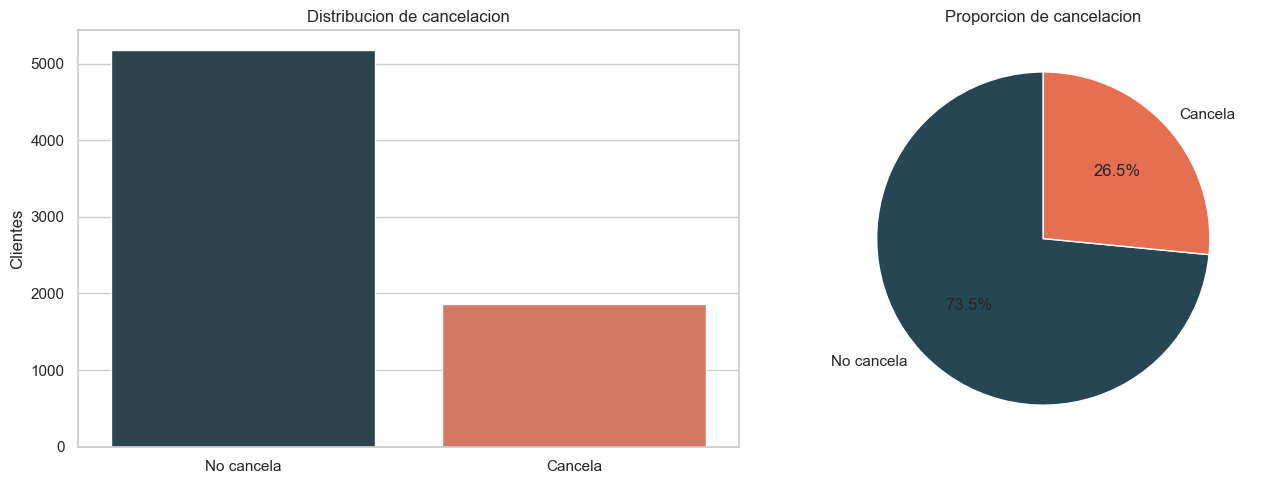

In [5]:
figura_distribucion = graficar_distribucion_clases(datos_limpios)
figura_distribucion.savefig(RUTA_GRAFICOS / "distribucion_clases.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Correlacion y seleccion de variables

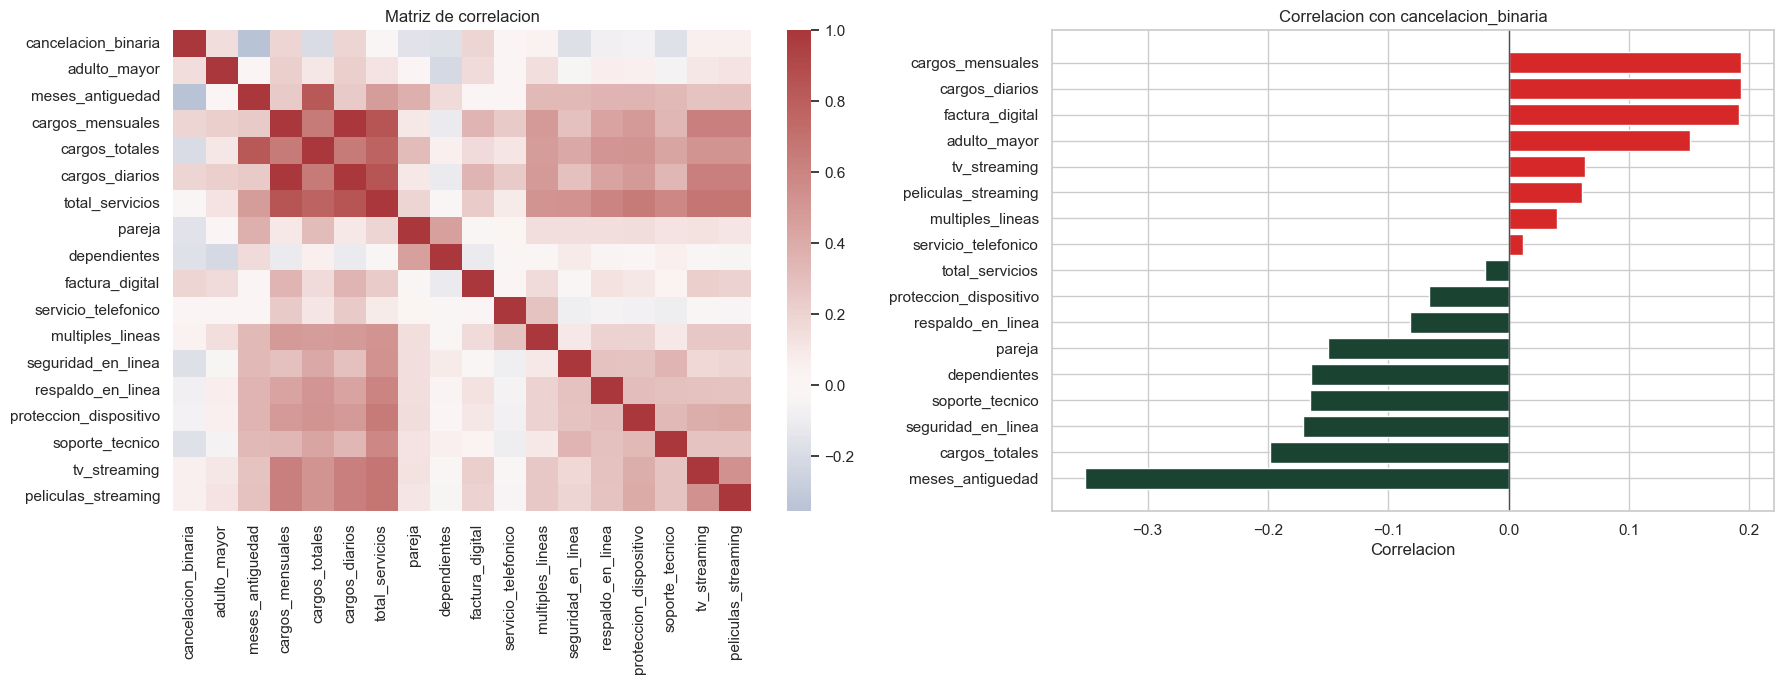

meses_antiguedad         -0.352229
cargos_totales           -0.198324
seguridad_en_linea       -0.171226
soporte_tecnico          -0.164674
dependientes             -0.164221
pareja                   -0.150448
respaldo_en_linea        -0.082255
proteccion_dispositivo   -0.066160
total_servicios          -0.019375
servicio_telefonico       0.011942
multiples_lineas          0.040102
peliculas_streaming       0.061382
tv_streaming              0.063228
adulto_mayor              0.150889
factura_digital           0.191825
cargos_diarios            0.193356
cargos_mensuales          0.193356
cancelacion_binaria       1.000000
Name: cancelacion_binaria, dtype: float64

In [6]:
figura_correlaciones, correlaciones_objetivo = graficar_correlaciones(datos_limpios)
figura_correlaciones.savefig(RUTA_GRAFICOS / "correlaciones_cancelacion.png", dpi=200, bbox_inches="tight")
plt.show()

correlaciones_objetivo.sort_values()

Las relaciones mas claras con la cancelacion son:

- `meses_antiguedad` y `cargos_totales` con correlacion negativa.
- `cargos_mensuales`, `factura_digital` y `adulto_mayor` con correlacion positiva.
- La ausencia de `seguridad_en_linea` y `soporte_tecnico` eleva el riesgo.

## 4. Analisis dirigido

Siguiendo el tablero, se revisan las relaciones entre permanencia, gasto y cancelacion.

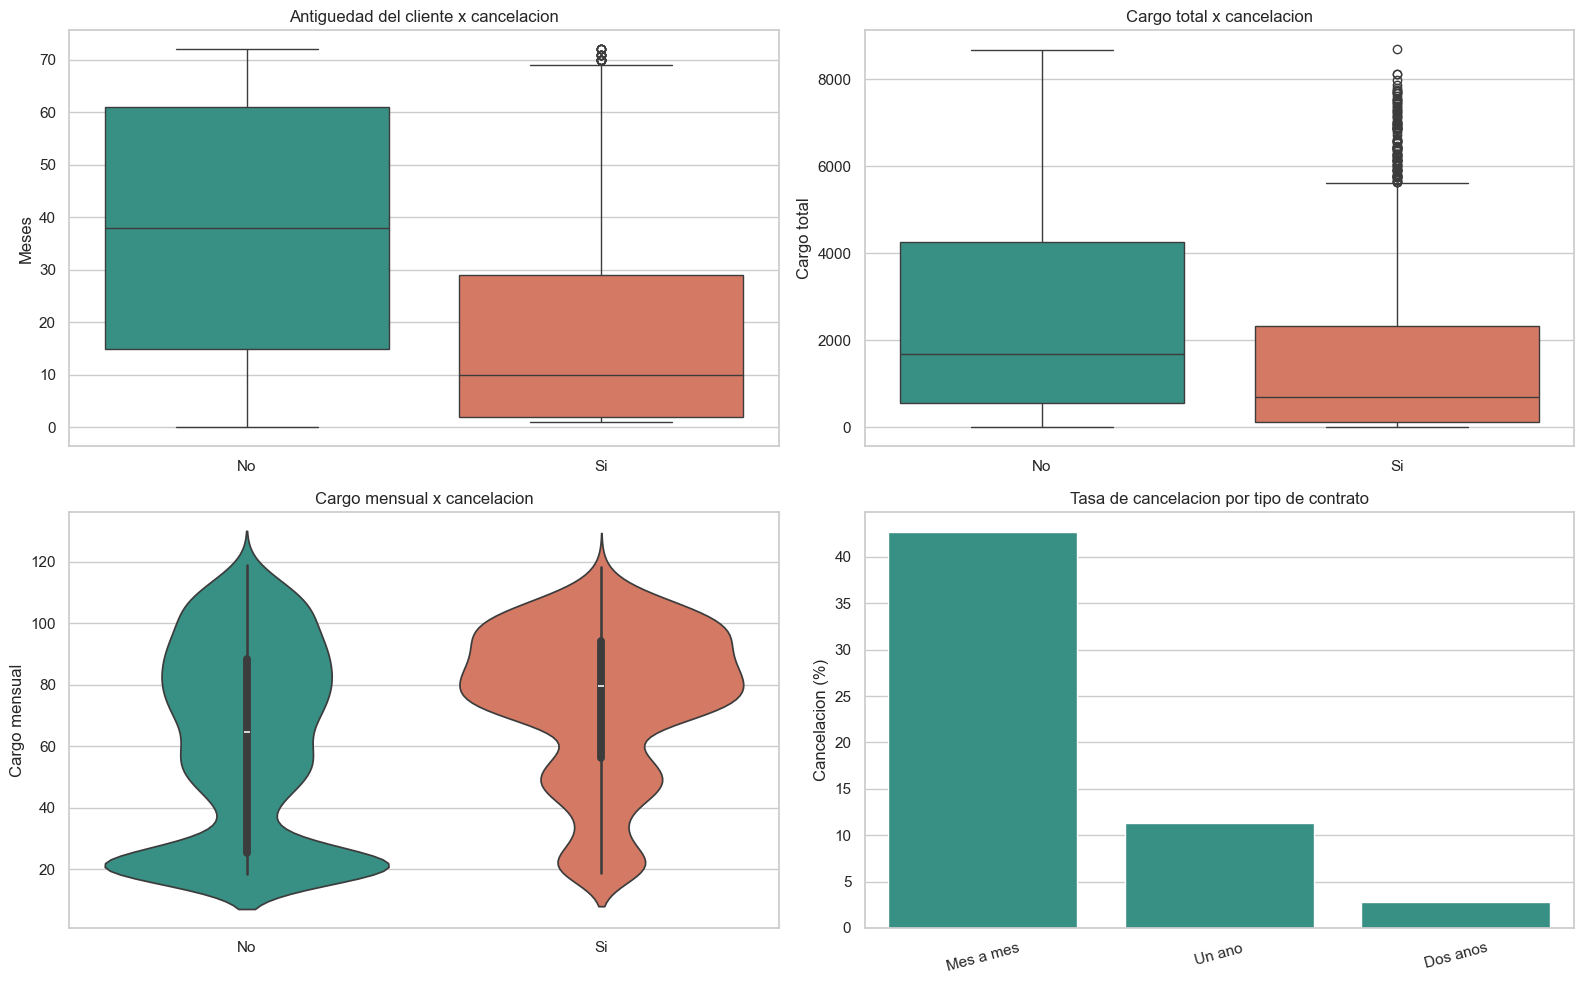

In [7]:
figura_analisis = graficar_analisis_dirigido(datos_limpios)
figura_analisis.savefig(RUTA_GRAFICOS / "analisis_dirigido.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
tasas_contrato = obtener_tabla_tasa_categorica(datos_limpios, "tipo_contrato")
tasas_pago = obtener_tabla_tasa_categorica(datos_limpios, "metodo_pago")
tasas_internet = obtener_tabla_tasa_categorica(datos_limpios, "servicio_internet")
resumen_numerico = obtener_resumen_numerico_por_cancelacion(datos_limpios)

display(tasas_contrato)
display(tasas_pago)
display(tasas_internet)
display(resumen_numerico)

,tipo_contrato,clientes,tasa_cancelacion
0,Mes a mes,3875,42.71
1,Un ano,1473,11.27
2,Dos anos,1695,2.83


,metodo_pago,clientes,tasa_cancelacion
0,Cheque electronico,2365,45.29
1,Cheque enviado por correo,1612,19.11
2,Transferencia bancaria automatica,1544,16.71
3,Tarjeta de credito automatica,1522,15.24


,servicio_internet,clientes,tasa_cancelacion
0,Fibra optica,3096,41.89
1,DSL,2421,18.96
2,Sin servicio,1526,7.40


,cancelacion,meses_antiguedad_mean,meses_antiguedad_median,cargos_mensuales_mean,cargos_mensuales_median,cargos_totales_mean,cargos_totales_median,total_servicios_mean,total_servicios_median
0,No,37.57,38.0,61.27,64.43,2549.91,1679.52,4.17,4.0
1,Si,17.98,10.0,74.44,79.65,1531.80,703.55,4.07,4.0


## 5. Modelado predictivo

Se comparan dos enfoques:

- **Regresion Logistica**: sensible a la escala, por eso usa estandarizacion.
- **Bosque Aleatorio**: no necesita escalamiento y captura relaciones no lineales.

In [9]:
X, y = preparar_datos_modelado(datos_limpios)
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = dividir_datos(X, y, proporcion_prueba=0.2)

print(f"Entrenamiento: {X_entrenamiento.shape}, Prueba: {X_prueba.shape}")

Entrenamiento: (5634, 20), Prueba: (1409, 20)


In [10]:
metricas_modelos, artefactos = comparar_modelos(X_entrenamiento, X_prueba, y_entrenamiento, y_prueba)
metricas_modelos

,modelo,division,exactitud,precision,recall,puntaje_f1,verdaderos_negativos,falsos_positivos,falsos_negativos,verdaderos_positivos
2,Bosque Aleatorio,entrenamiento,0.7952,0.5782,0.8435,0.6861,3219,920,234,1261
0,Regresion Logistica,entrenamiento,0.7520,0.5211,0.8107,0.6344,3025,1114,283,1212
3,Bosque Aleatorio,prueba,0.7672,0.5429,0.7781,0.6396,790,245,83,291
1,Regresion Logistica,prueba,0.7395,0.5060,0.7861,0.6157,748,287,80,294


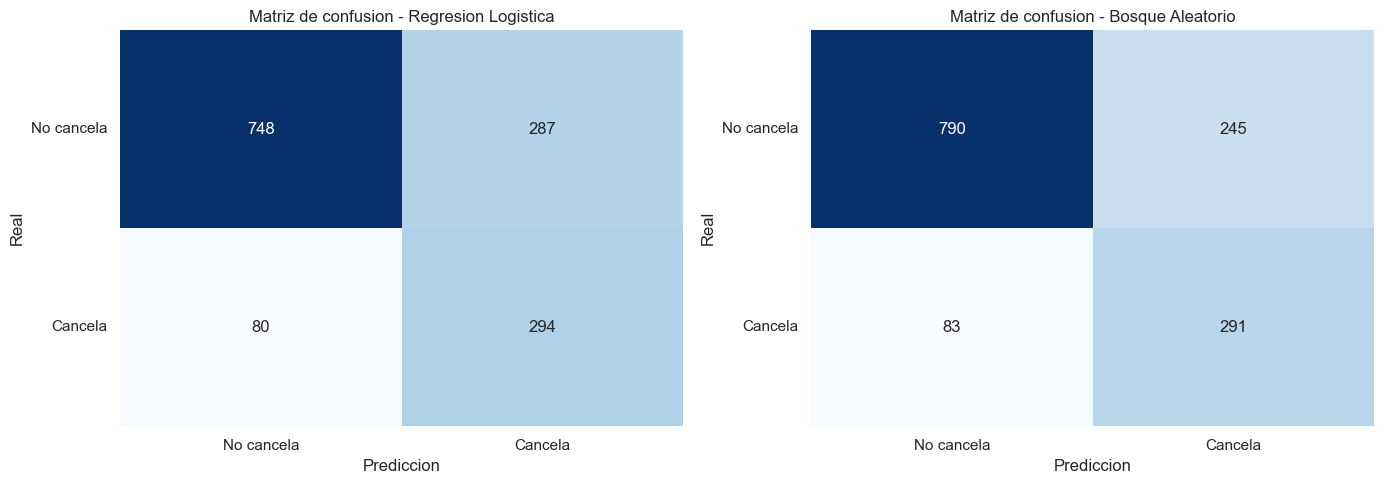

In [11]:
figura_confusion = graficar_matrices_confusion(artefactos)
figura_confusion.savefig(RUTA_GRAFICOS / "matrices_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Importancia de variables

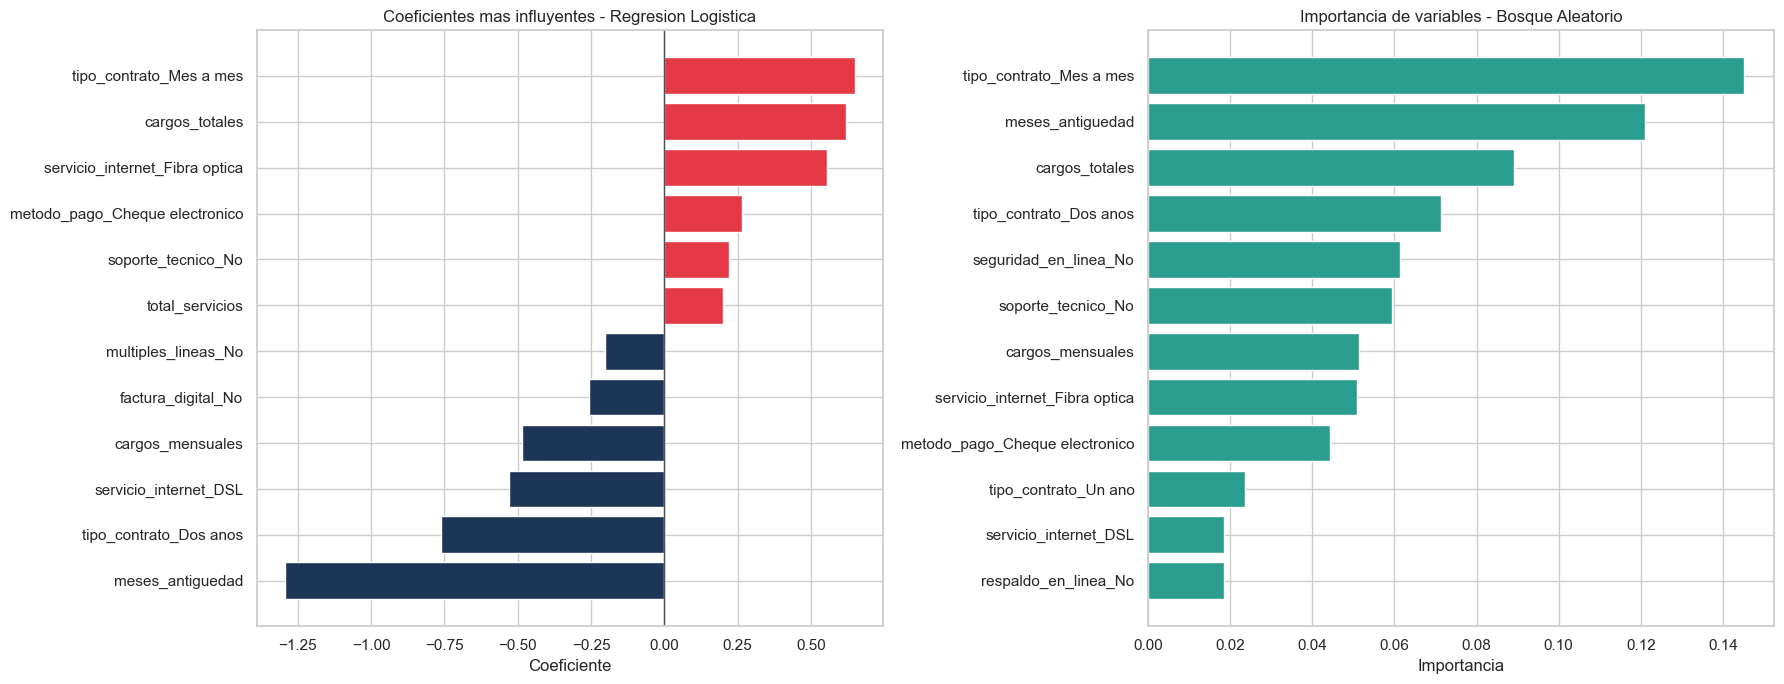

,coeficiente
meses_antiguedad,-1.292059
tipo_contrato_Dos anos,-0.759577
tipo_contrato_Mes a mes,0.648443
cargos_totales,0.619221
servicio_internet_Fibra optica,0.553800
servicio_internet_DSL,-0.528400
cargos_mensuales,-0.486124
metodo_pago_Cheque electronico,0.264782
factura_digital_No,-0.255367
soporte_tecnico_No,0.220756


,importancia
tipo_contrato_Mes a mes,0.145137
meses_antiguedad,0.121024
cargos_totales,0.089132
tipo_contrato_Dos anos,0.071395
seguridad_en_linea_No,0.061274
soporte_tecnico_No,0.059327
cargos_mensuales,0.051488
servicio_internet_Fibra optica,0.050952
metodo_pago_Cheque electronico,0.044302
tipo_contrato_Un ano,0.023754


In [12]:
coeficientes_logit, importancias_bosque = obtener_importancia_variables(artefactos, top_n=12)

figura_importancia = graficar_importancia_variables(coeficientes_logit, importancias_bosque)
figura_importancia.savefig(RUTA_GRAFICOS / "importancia_variables.png", dpi=200, bbox_inches="tight")
plt.show()

display(coeficientes_logit.to_frame("coeficiente"))
display(importancias_bosque.to_frame("importancia"))

## 7. Conclusiones

### Hallazgos tecnicos

- **Bosque Aleatorio** obtuvo el mejor equilibrio entre exactitud y puntaje F1 en prueba.
- **Regresion Logistica** mantuvo el mejor recall, util cuando el negocio prioriza detectar la mayor cantidad posible de clientes en riesgo.
- Limitar la complejidad del bosque redujo el sobreajuste frente a una configuracion mas agresiva.

### Variables mas influyentes

- Tipo de contrato **Mes a mes**
- Menor **meses_antiguedad**
- Mayor nivel de **cargos**
- Ausencia de **seguridad_en_linea** y **soporte_tecnico**
- Servicio **Fibra optica**
- Metodo de pago **Cheque electronico**

### Recomendaciones de negocio

1. Priorizar campanas tempranas para clientes nuevos con contrato mes a mes.
2. Ofrecer paquetes con seguridad y soporte para clientes de fibra optica.
3. Revisar fricciones del canal `Cheque electronico`, que concentra la tasa mas alta de cancelacion.
4. Usar la Regresion Logistica como alerta temprana y el Bosque Aleatorio como referencia operativa por su mejor balance global.